In [42]:
library(ggplot2)
library(readr)
library(tidyverse)
library(lubridate)
library(scales)
library(Cairo)
library(wesanderson)
library(dplyr)

In [43]:
# Thanks https://stats.andrewheiss.com/misc/gantt.html

permanent_lab_members <- read.delim("lab_members.txt")
#change this to the current date to update all current lab members
date <- "2025-06-15"
permanent_lab_members$End[permanent_lab_members$End=="today"]<-date





In [44]:
#Count number of UG trainees
UGs <- permanent_lab_members[permanent_lab_members$Project == "undergraduate", ]

UGs_count <- UGs %>%
  nrow()
print(UGs_count)

message <- paste("I've worked with", 
                 UGs_count, 
                 "undergraduate trainees since 2019 in my lab at UW. Prior to this I directly supervised 11 undergraduates at UC San Diego (7), UC Berkeley (3), and Tufts University (1)"
                )
print(message)

print(UGs)

[1] 28
[1] "I've worked with 28 undergraduate trainees since 2019 in my lab at UW. Prior to this I directly supervised 11 undergraduates at UC San Diego (7), UC Berkeley (3), and Tufts University (1)"
                   Task       Project      Start        End keep
3        Anthony Garcia undergraduate 2019-10-01 2021-06-16    1
7         Brian Behnken undergraduate 2022-02-01 2023-08-31    1
11        Morgan Alonso undergraduate 2022-09-01 2024-06-01    0
12   Cora Werner Lovell undergraduate 2022-09-01 2024-06-01    0
13          Aster Earls undergraduate 2023-09-01 2025-12-31    0
14            Ty Bryant undergraduate 2023-09-01 2025-03-01    0
15        Nick Peterson undergraduate 2023-09-01 2025-06-15    0
16        Euan McCubbin undergraduate 2024-01-01 2025-06-15    1
18    Ava Kloss-Schmidt undergraduate 2019-10-01 2022-06-01    0
20           August Liu undergraduate 2021-01-06 2021-05-30    0
21       Sanjana Jadhav undergraduate 2021-01-25 2021-06-15    0
22           Sandy 

In [45]:
#Count number of non-UG trainees
nonUGs <- permanent_lab_members[!(permanent_lab_members$Project %in% c("undergraduate", "PI", "rotation student")), ]

nonUGs_count <- nonUGs %>%
  nrow()
print(nonUGs_count)

message2 <- paste("I've worked with", nonUGs_count, "technicians, graduate students, and postdocs since 2019")
print(message2)

print(nonUGs)

[1] 10
[1] "I've worked with 10 technicians, graduate students, and postdocs since 2019"
                        Task          Project      Start        End keep
2             Tonio Chaparro       technician 2019-09-01 2022-06-01    1
4             Anthony Garcia       technician 2021-06-16 2022-09-01    1
5               Simon Snoeck          postdoc 2019-11-01 2023-01-01    1
6  Natalia Guayazan-Palacios graduate student 2020-01-01 2025-06-15    1
8              Brian Behnken       technician 2023-09-01 2025-06-15    1
9               Ben Sheppard graduate student 2022-04-01 2025-06-15    1
10             Wesley George       technician 2022-09-01 2023-09-01    1
17             Di 'Woody' Wu          postdoc 2023-10-01 2025-06-15    1
41               Kelsey Wood          postdoc 2024-11-01 2025-06-15    1
45                 Amy Moore graduate student 2025-01-01 2025-06-15    1


In [46]:
#keep only the rows that don't meet the condition of being an undergraduate or rotation student with an "End" value of "today"
removed_entries <- permanent_lab_members %>%
  filter(keep == 0)

permanent_lab_members <- permanent_lab_members %>%
  filter(keep == 1)


print(permanent_lab_members)


                        Task          Project      Start        End keep
1          Adam Steinbrenner               PI 2019-08-31 2025-06-15    1
2             Tonio Chaparro       technician 2019-09-01 2022-06-01    1
3             Anthony Garcia    undergraduate 2019-10-01 2021-06-16    1
4             Anthony Garcia       technician 2021-06-16 2022-09-01    1
5               Simon Snoeck          postdoc 2019-11-01 2023-01-01    1
6  Natalia Guayazan-Palacios graduate student 2020-01-01 2025-06-15    1
7              Brian Behnken    undergraduate 2022-02-01 2023-08-31    1
8              Brian Behnken       technician 2023-09-01 2025-06-15    1
9               Ben Sheppard graduate student 2022-04-01 2025-06-15    1
10             Wesley George       technician 2022-09-01 2023-09-01    1
11             Euan McCubbin    undergraduate 2024-01-01 2025-06-15    1
12             Di 'Woody' Wu          postdoc 2023-10-01 2025-06-15    1
13             Amelia Wayman    undergraduate 2024-

In [47]:

# Convert data to long for ggplot
permanent_lab_members.long <- permanent_lab_members %>%
  mutate(Start = ymd(Start),
         End = ymd(End)) %>%
  gather(date.type, task.date, -c(Project, Task, keep)) %>%
  group_by(Task) %>%
  mutate(Start_Date = min(task.date)) %>%
  ungroup() %>%
  arrange(Start_Date, date.type, task.date) %>%
  mutate(Task = factor(Task, levels=rev(unique(Task)), ordered=TRUE))

removed_entries <- removed_entries %>%
  mutate(Start = ymd(Start),
         End = ymd(End)) %>%
  gather(date.type, task.date, -c(Project, Task, keep)) %>%
  group_by(Task) %>%
  mutate(Start_Date = min(task.date)) %>%
  ungroup() %>%
  arrange(Start_Date, date.type, task.date) %>%
  mutate(Task = factor(Task, levels=rev(unique(Task)), ordered=TRUE))


# Custom theme for making a clean Gantt chart
theme_gantt <- function(base_size=11, base_family="sans") {
  ret <- theme_bw(base_size, base_family) %+replace%
    theme(panel.background = element_rect(fill="#ffffff", colour=NA),
          axis.title.x=element_text(vjust=-0.2), axis.title.y=element_text(vjust=1.5),
          title=element_text(vjust=1.2, family="Source Sans Pro Semibold"),
          panel.border = element_blank(), axis.line=element_blank(),
          panel.grid.minor=element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.major.x = element_line(size=0.5, colour="grey80"),
          axis.ticks=element_blank(),
          legend.position="bottom",
          legend.box = "vertical",
          legend.box.just = "left",
          legend.margin = margin(t = 0, r = 0, b = 0, l = 0, unit = "pt"),
          legend.spacing.x = unit(0.2, 'cm'),
          legend.spacing.y = unit(0.2, 'cm'),
          legend.box.spacing = unit(0.2, 'cm'),
          legend.key.size = unit(0.5, 'lines'),
          legend.text = element_text(size = rel(0.8)),
          axis.title=element_text(size=rel(0.8), family="Source Sans Pro Semibold"),
          strip.text=element_text(size=rel(1), family="Source Sans Pro Semibold"),
          strip.background=element_rect(fill="#ffffff", colour=NA),
          panel.spacing.y=unit(1.5, "lines"),
          legend.key = element_blank())
  
  ret
}
  


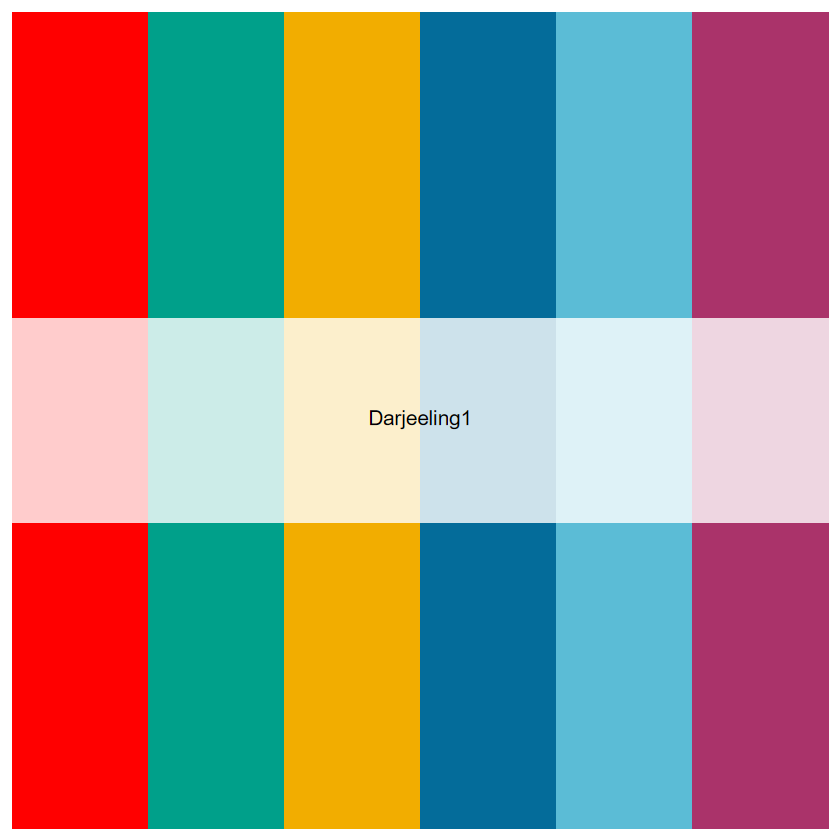

In [48]:
# Calculate where to put the dotted lines that show up every three entries
#x.breaks <- seq(length(tasks$Task) + 0.5 - 3, 0, by=-3)
x.breaks <- seq(length(permanent_lab_members$Task) + 0.5, 0, by=-3)


pal <- wes_palette("Darjeeling1", 5, type = "discrete")
pal[4]<-"#046C9A"
pal[6]<-"#AA336A"
print(pal)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


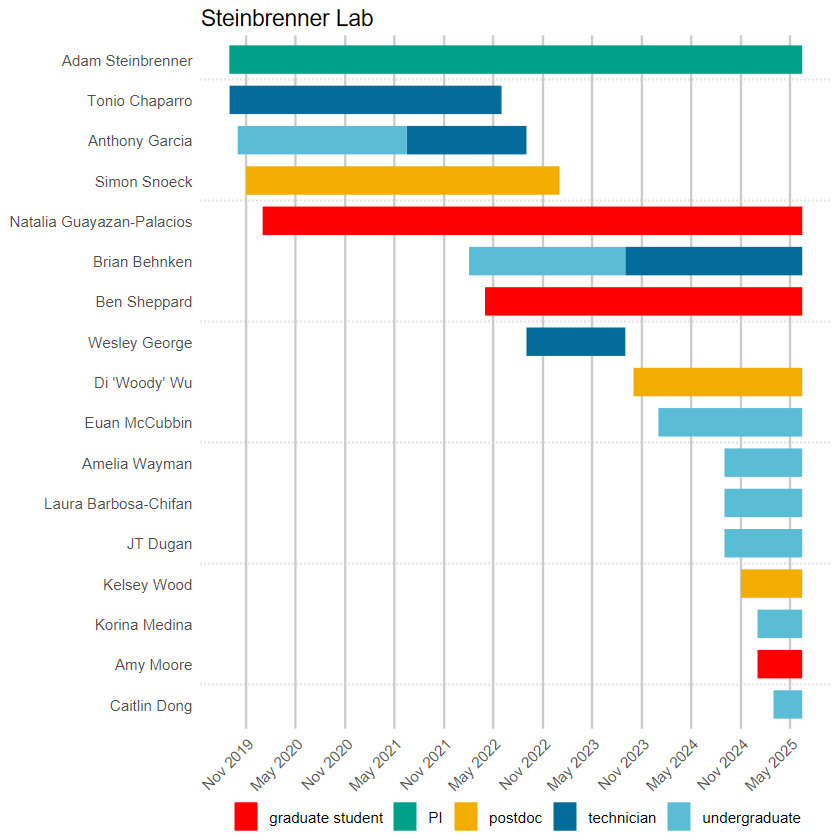

In [49]:
# Build plot
timeline <- ggplot(permanent_lab_members.long, aes(x=Task, y=task.date, colour=Project)) + 
  geom_line(size=6) + 
  #geom_vline(xintercept=x.breaks, colour="grey80", linetype="dotted") + 
  guides(colour=guide_legend(title=NULL)) +
  labs(x=NULL, y=NULL) + coord_flip() +
  scale_y_date(date_breaks="6 months", labels=date_format("%b %Y")) +
  theme_gantt() + theme(axis.text.x=element_text(angle=45, hjust=1)) + scale_color_manual(values=pal) +ggtitle("Steinbrenner Lab") +
  #reorder the list according to the input text document
scale_x_discrete(limits = rev(unique(permanent_lab_members.long$Task))) +
  geom_vline(xintercept=x.breaks, colour="grey80", linetype="dotted")

timeline

In [50]:
filtered_removed_entries <- removed_entries[removed_entries$date.type == "End", ]
write.csv(filtered_removed_entries, "previous_UG_rotations.csv", row.names=FALSE)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


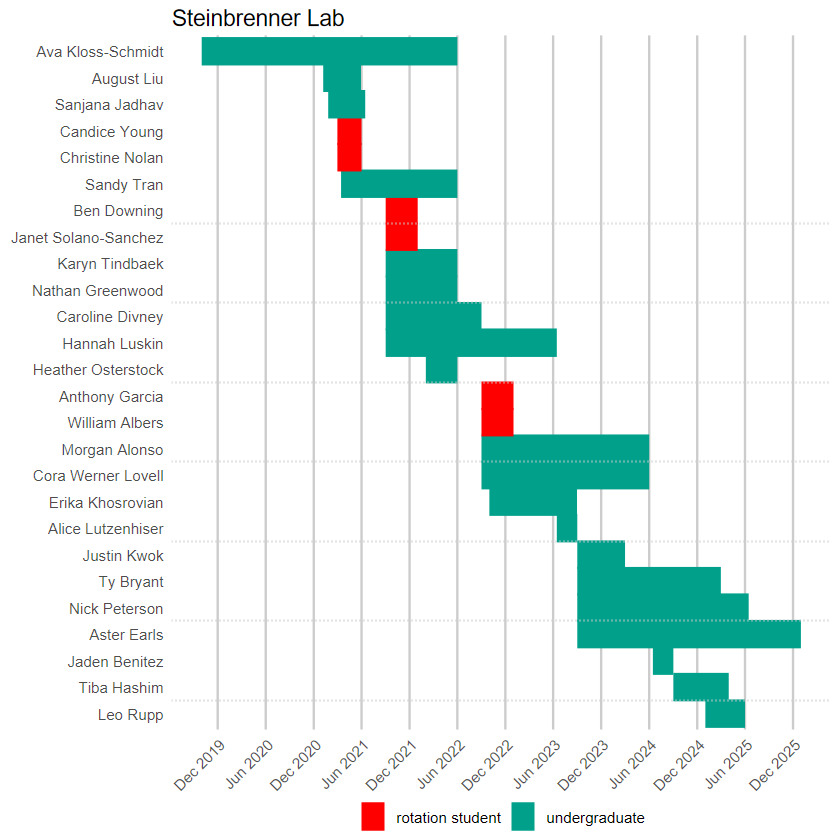

In [51]:
# Build plot
timeline2 <- ggplot(removed_entries, aes(x=Task, y=task.date, colour=Project)) + 
  geom_line(size=6) + 
  #geom_vline(xintercept=x.breaks, colour="grey80", linetype="dotted") + 
  guides(colour=guide_legend(title=NULL)) +
  labs(x=NULL, y=NULL) + coord_flip() +
  scale_y_date(date_breaks="6 months", labels=date_format("%b %Y")) +
  theme_gantt() + theme(axis.text.x=element_text(angle=45, hjust=1)) + scale_color_manual(values=pal) +ggtitle("Steinbrenner Lab") +
  #reorder the list according to the input text document
scale_x_discrete(limits = rev(unique(removed_entries$Task))) +
  geom_vline(xintercept=x.breaks, colour="grey80", linetype="dotted")


timeline2

In [52]:
#ggsave("~/08_website/github/steinbrennerlab.github.io/lab_members.png",width=6,height=8,timeline)
ggsave("lab_members.png",width=6,height=5,timeline)
ggsave("previous_UG_rotations.png",width=6,height=5,timeline2)